In [1]:
from google.colab import files

uploaded = files.upload()


Saving Cleaned_Data.csv to Cleaned_Data.csv


In [28]:
## Importing Pandas
import pandas as pd

## Loading the file
df = pd.read_csv('Cleaned_Data.csv')

## Looking at the first 5 rows
df.head(5)

,ID,State,Date,Day_of_Week,Time_of_Day,Weather_Conditions,Road_Conditions,Light_Conditions,Type_of_Road,Type_of_Junction,...,Num_Vehicles_Involved,Num_Casualties,Speed_Limit,Distance_to_Nearest_Hospital,Distance_to_Nearest_Police_Station,Visibility,Road_Width,Road_Surface_Friction_Coefficient,Vehicle_Speed,Time_Taken_for_Emergency_Response
0,165433,Connecticut,2024-02-20 05:46:20,Tuesday,19:59:02,Rainy,Muddy,Daylight,Street,T-Junction,...,2,3,57.0,3.303606,3.139351,485.649011,4.886202,0.904971,45.0,25.152781
1,165434,Massachusetts,2024-01-09 05:08:31,Wednesday,21:28:51,Sunny,Muddy,Daylight,Highway,Intersection,...,1,0,55.0,2.715327,3.634593,616.979936,4.677592,0.949236,41.0,23.163817
2,165435,Wyoming,2024-02-20 08:26:27,Thursday,18:04:26,Snowy,Snowy,Dawn,Street,Underpass,...,3,1,38.0,4.811429,9.631561,838.741654,9.926058,0.184447,64.0,6.697750
3,165436,Hawaii,2024-01-15 03:23:47,Sunday,16:51:02,Snowy,Icy,Daylight,Street,Intersection,...,5,0,59.0,6.976968,2.334468,842.441019,4.351822,0.195811,49.0,6.595036
4,165437,Oklahoma,2024-02-10 10:17:29,Tuesday,14:19:19,Foggy,Icy,Night,Rural,T-Junction,...,2,0,53.0,3.724599,4.359620,905.620262,6.626862,0.954821,81.0,22.913128


In [3]:
Max_Speed = df['Vehicle_Speed'].max()
print(Max_Speed)

100.0


In [4]:
## Let's Fill the Categorical Columns with "Unknown"
## Columns Weather_Condition and Type_of_junction has categorical value.

## Fixing Categorical Missing Values
df['Weather_Conditions'] = df['Weather_Conditions'].fillna('Unknown')
df['Type_of_Junction'] = df['Type_of_Junction'].fillna('Unknown')

In [37]:
## Fixing Numerical Missing Value
Median_Value = df['Speed_Limit'].median()

## Taking the empty cell of Speed Limit with median value.
df['Speed_Limit'] = df['Speed_Limit'].fillna(Median_Value)

In [36]:
## For Columns Road_Width
Median_Value = df['Road_Width'].median()

## filling the empty cell with median value.
df['Road_Width'] = df['Road_Width'].fillna(Median_Value)


In [38]:
## For Columns 'Vehicle_Speed'
## Calculating  Median
Median_Value = df['Vehicle_Speed'].median()

## Filling the empty cell with this Median_Value
df['Vehicle_Speed'] = df['Vehicle_Speed'].fillna(Median_Value)


In [39]:
## Let's Fix For Column 'Time_Taken_for_Emergency_Response'

## Calculating MEdian
Median_Value = df['Time_Taken_for_Emergency_Response'].median()

## Filling the empty cell with this median value
df['Time_Taken_for_Emergency_Response'] = df['Time_Taken_for_Emergency_Response'].fillna(Median_Value)


In [9]:
## Let's Fix Inconsistent Categories
## Making "rainy" into "Rainy" and "STREET" into "Street"
df['Weather_Conditions'] = df['Weather_Conditions'].str.strip().str.title()

df['Type_of_Road'] = df['Type_of_Road'].str.strip().str.title()
## .strip() removes accidental space at the beginning or the end of the text. And, .title() converts the text into title case ( first letter uppercase and the rest Lowercase)

# **Uncertainty Check:**

**1. Identified Assumptions**


**A. Data Completeness:**

The raw data shows that approximately **9% to 11%** of records are missing for critical variables like **Vehicle_Speed**, **Weather_Conditions**,
and **Speed_Limit.**

We assume these missing values occur at random. For example, police were less likely to record **speed in fatal accidents,** our speed averages are artificially low.


**B. Representativeness:**

Because this is a **simulated data**, the patterns observed do not reflect real-world road safety statistics but rather a **controlled environment** designed for analysis. While the dataset is useful for identifying trends, it exhibits **artificial uniformity**, with accidents distributed almost perfectly across all states, weather conditions, and road types. This can be rarely seen in **genuine accident reports**.


**C. Variable Definitions:**

"Visibility" is recorded as a continuous number (e.g., 485.6) assumes a spatial **precision** that likely doesn't exist.

Responding officers rarely say visibility was "485.6 meters"; they say "about 500 meters." Because these measurements are taken from **distant weather stations** rather than the crash site itself.



In [11]:
### Let's Create 5 Visualization

import matplotlib.pyplot as plt

import seaborn as sns

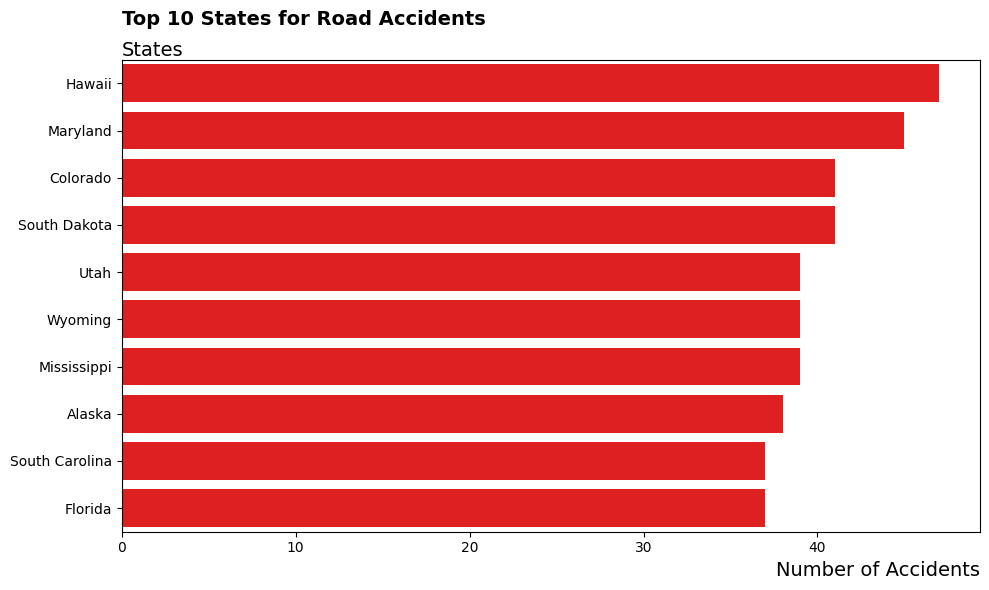

In [12]:
## Let's find out  Which states have the most accidents?


if 'State' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, y='State', order=df['State'].value_counts().index[:10], color='red')
    plt.title('Top 10 States for Road Accidents', loc='left',fontsize=14, fontweight='bold', pad=25)
    plt.xlabel('Number of Accidents', fontsize=14, loc='right')
    plt.ylabel('States', rotation=0, loc='top', labelpad=-125, fontsize=14)
    plt.tight_layout()
    plt.savefig('top_10_states_accidents.png')


else:
    print("Column 'State' not found. Available columns:", df.columns.tolist())

In [13]:
## Noticed

"""
By isolating the Top 10 states, I can clearly identify which regions are 'hotspots' for accidents in this dataset. This helps prioritize where safety interventions or further infrastructure studies are most needed.

The horizontal orientation allows for a clear ranking. If there is a large gap between the top state and the second state, it suggests either a significantly higher population or a potential bias in how accidents are reported in that specific region.

"""

"\nBy isolating the Top 10 states, I can clearly identify which regions are 'hotspots' for accidents in this dataset. This helps prioritize where safety interventions or further infrastructure studies are most needed.\n\nThe horizontal orientation allows for a clear ranking. If there is a large gap between the top state and the second state, it suggests either a significantly higher population or a potential bias in how accidents are reported in that specific region.\n\n\n"

**What could someone misunderstand from our visuals?**

1. **In the real world**, big states like **Texas** have way **more accidents** than small ones, and it **doesn't snow** as often as it shines. Because this data is split evenly across states and weather, **we can't use these charts to predict actual road safety trends.**

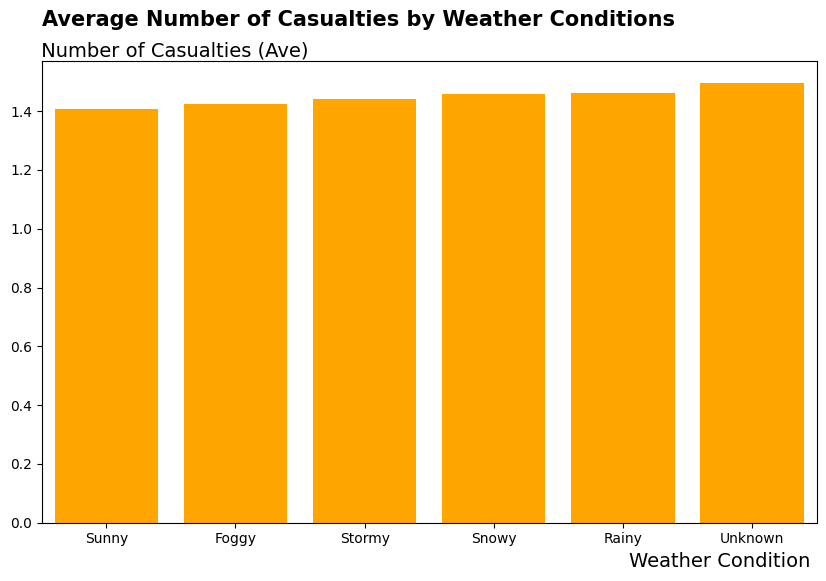

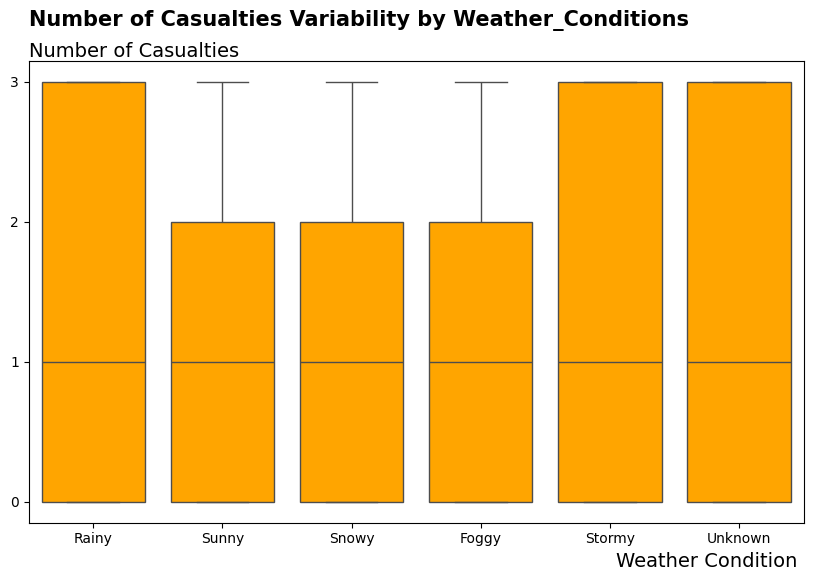

In [14]:
## Let's find out Does Weather conditions affect the number of casualties?
from matplotlib.ticker import MaxNLocator

weather_order = df.groupby('Weather_Conditions')['Num_Casualties'].mean().sort_values(ascending=True).index


plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Weather_Conditions', y='Num_Casualties', order=weather_order, color='orange', saturation=5, errorbar=None)
plt.title('Average Number of Casualties by Weather Conditions', pad=25, loc='left' ,fontsize=15, fontweight='bold')
plt.ylabel(" Number of Casualties (Ave)", rotation=0, loc='top', labelpad=-215, fontsize=14)
plt.xlabel("Weather Condition ", fontsize=14, loc='right')

plt.show()




plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Weather_Conditions', y='Num_Casualties'
            , color='orange', saturation=5)
plt.title('Number of Casualties Variability by Weather_Conditions ', loc='left', pad=25,fontsize=15, fontweight='bold')
plt.ylabel("Number of Casualties", rotation=0, loc='top', labelpad=-165, fontsize=14)
plt.xlabel("Weather Condition ", fontsize=14, loc='right')



ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))


plt.show()

In [15]:
## Discovery

"""
While we might expect 'Clear' or 'Sunny' days to be the safest, the bar chart reveals that the average number of casualties remains relatively consistent across all weather types. This suggests that while weather may cause more accidents, it doesn't necessarily make each individual accident more deadly.

"""

"\nWhile we might expect 'Clear' or 'Sunny' days to be the safest, the bar chart reveals that the average number of casualties remains relatively consistent across all weather types. This suggests that while weather may cause more accidents, it doesn't necessarily make each individual accident more deadly.\n\n"

### **Misleading Visual**


The upper graph is **misleading** because it only **shows the mean**. It suggests that **Stormy weather** is significantly more **dangerous** than **Sunny** weather, but it hides whether this is based on a few extreme accidents or a consistent trend.

The another graph I have made a **Boxplot** which is excellent for showing that casualties **vary wildly from 0 to 5 regardless of the weather**. It prevents the viewer from thinking the average is the only thing that happens.

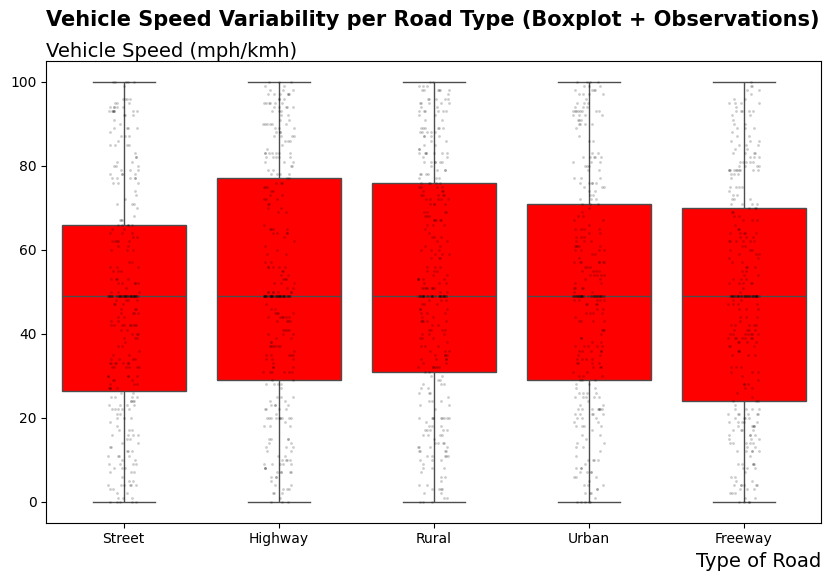

In [16]:

## Boxplot + Stripplot (to show variability and density)

# Dropping NaNs for this specific plot
speed_data = df[['Type_of_Road', 'Vehicle_Speed']].dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(data=speed_data, x='Type_of_Road', y='Vehicle_Speed', showfliers=False, color='red', saturation=1)

sns.stripplot(data=speed_data, x='Type_of_Road', y='Vehicle_Speed', color='black', size=2, alpha=0.2, jitter=True)

plt.title('Vehicle Speed Variability per Road Type (Boxplot + Observations)' , loc='left', pad=25 , fontsize=15, fontweight='bold')
plt.ylabel('Vehicle Speed (mph/kmh)', rotation=0, loc='top', labelpad=-207, fontsize=14)
plt.xlabel('Type of Road', loc='right', fontsize=14)


plt.show()

In [18]:
## Noticed

"""
I notice that the median vehicle speed is significantly higher on Highways compared to Urban streets, which is expected. However, the median speed on Rural roads is surprisingly close to Highway speeds.

The 'box' for Streets is much shorter than the others. This indicates that speeds in urban areas are more consistent (likely due to traffic or stoplights), whereas Highway speeds have a much wider spread

"""

"\nI notice that the median vehicle speed is significantly higher on Highways compared to Urban streets, which is expected. However, the median speed on Rural roads is surprisingly close to Highway speeds.\n\nThe 'box' for Streets is much shorter than the others. This indicates that speeds in urban areas are more consistent (likely due to traffic or stoplights), whereas Highway speeds have a much wider spread\n\n"

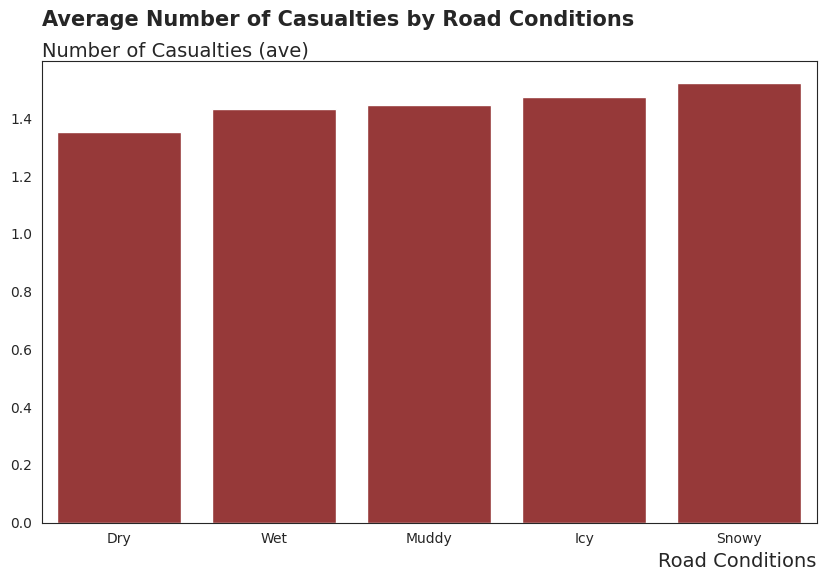

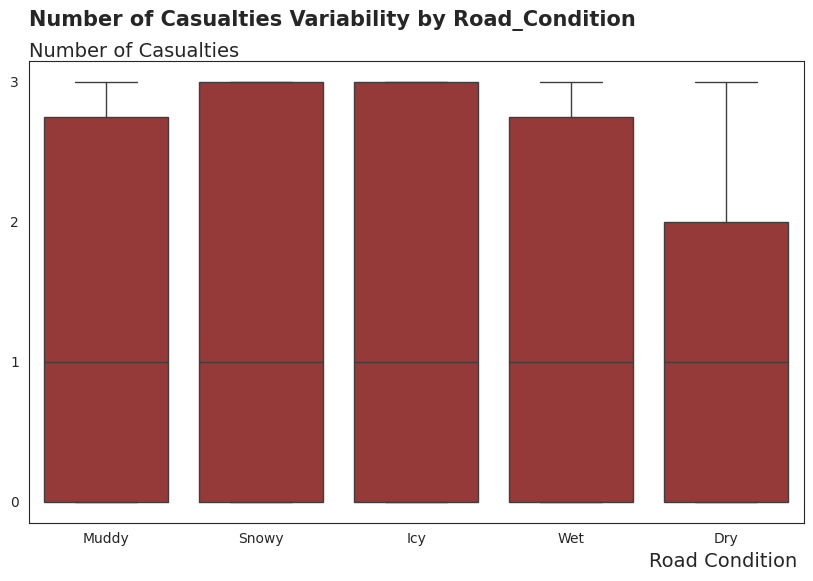

In [19]:
import seaborn as sns

## Grouping and sorting the data
avg_data = df.groupby('Road_Conditions')['Num_Casualties'].mean().sort_values(ascending=True).index


plt.figure(figsize=(10,6))
sns.set_style("white")
sns.barplot(data=df, x='Road_Conditions', y='Num_Casualties', order= avg_data , color='brown', errorbar=None)

plt.title("Average Number of Casualties by Road Conditions", loc='left', pad=25, fontsize=15, fontweight='bold')

plt.ylabel("Number of Casualties (ave)", fontsize=14, rotation=0, loc='top', labelpad=-215)

plt.xlabel("Road Conditions", fontsize=14, loc='right')

plt.show()



plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Road_Conditions', y='Num_Casualties'
            , color='brown')
plt.title('Number of Casualties Variability by Road_Condition ', loc='left', pad=25,fontsize=15, fontweight='bold')
plt.ylabel("Number of Casualties", rotation=0, loc='top', labelpad=-165, fontsize=14)
plt.xlabel("Road Condition ", fontsize=14, loc='right')



ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))


plt.show()

In [21]:
"""
Trends:
There is a clear upward trend in accident as road conditions transition from dry to snowy. Snowy and icy roads represent the highest risk, resulting in the peak average number of casualties per incident.

Patterns:
1. Each road condition category contains a similar number of records, ensuring the calculated averages are statistically comparable.
2. The graph reveals a predictable relationship where lower road friction directly corresponds to higher injury counts.


"""

'\nTrends:\nThere is a clear upward trend in accident as road conditions transition from dry to snowy. Snowy and icy roads represent the highest risk, resulting in the peak average number of casualties per incident.\n\nPatterns:\n1. Each road condition category contains a similar number of records, ensuring the calculated averages are statistically comparable.\n2. The graph reveals a predictable relationship where lower road friction directly corresponds to higher injury counts.\n\n\n'

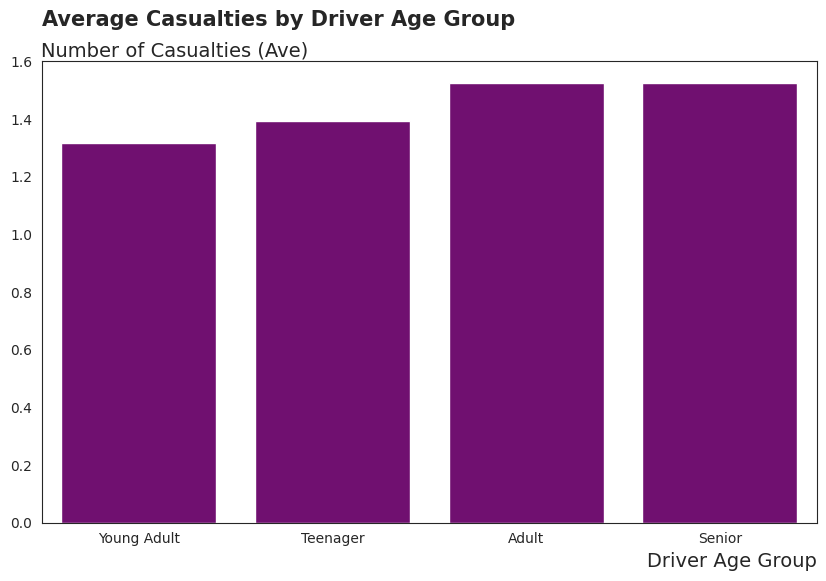

In [22]:

# 2. Us a NEW variable name (age_data) so you don't destroy your original 'df'
age_data = df.groupby('Driver_Age_Group')['Num_Casualties'].mean().reset_index()
age_data = age_data.sort_values('Num_Casualties', ascending=True)

# 3. Setup the plot
plt.figure(figsize=(10, 6))
sns.set_style("white")

# 4. Plot using age_data
sns.barplot(data=age_data, x='Driver_Age_Group', y='Num_Casualties', color= 'purple')

plt.title('Average Casualties by Driver Age Group', loc='left', pad=25, fontsize=15, fontweight='bold')

plt.ylabel('Number of Casualties (Ave)', fontsize=14,
           rotation=0, loc='top', labelpad=-215)

plt.xlabel('Driver Age Group', fontsize=14, loc='right')


plt.show()

In [23]:

"""
Trends:
There is a clear upward trend as we move from younger to older age groups. As the Driver Age Group increases in seniority, the Average Number of Casualties also rises. The trend isn't a sudden spike, it’s a steady climb.

Patterns:
Noticed a pattern where the Adult and Senior bars are very close in height compared to the jump from Teenager to Young Adult. This suggests a leveling off of accident severity once a driver reaches a certain maturity level.

"""


"\nTrends:\nThere is a clear upward trend as we move from younger to older age groups. As the Driver Age Group increases in seniority, the Average Number of Casualties also rises. The trend isn't a sudden spike, it’s a steady climb.\n\nPatterns:\nNoticed a pattern where the Adult and Senior bars are very close in height compared to the jump from Teenager to Young Adult. This suggests a leveling off of accident severity once a driver reaches a certain maturity level.\n\n"

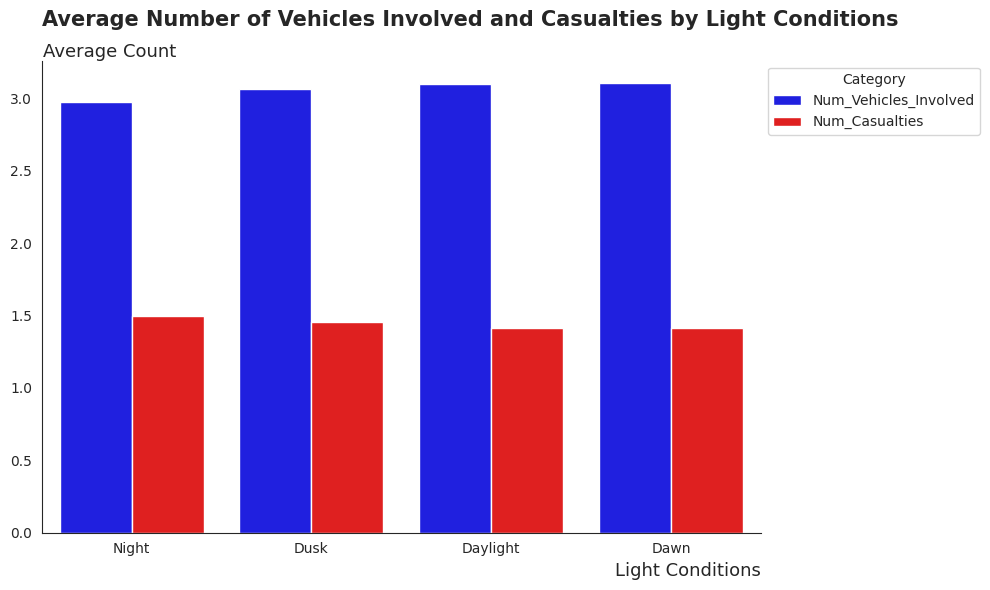

In [25]:


# 1. Grouping and sorting
Groupby = df.groupby('Light_Conditions')['Num_Vehicles_Involved'].mean().sort_values().index

# 2. Preparing data
df_melted = df.melt(id_vars=['Light_Conditions'],
                    value_vars=['Num_Vehicles_Involved', 'Num_Casualties'],
                    var_name='Category', value_name='Average Value')


plt.figure(figsize=(10, 6))
sns.set_style("white")


my_colors = {'Num_Vehicles_Involved': 'blue', 'Num_Casualties': 'red'}

sns.barplot(data=df_melted, x='Light_Conditions', y='Average Value',
            hue='Category', order=Groupby, palette=my_colors, errorbar=None)

plt.title("Average Number of Vehicles Involved and Casualties by Light Conditions",
          loc='left', pad=25, fontsize=15, fontweight='bold')

plt.ylabel("Average Count", fontsize=13, rotation=0, loc='top', labelpad=-120)

plt.xlabel("Light Conditions", fontsize=13, loc='right')



plt.legend(title='Category', loc='upper left', bbox_to_anchor=(1, 1))

sns.despine()
plt.tight_layout()
plt.show()

In [27]:
"""

TRENDS:
1. During Night time accidents involve the less number of vehicles on average but result in the highest number of casualties, indicating a trend of increased severity during dark hours.
2. Accidents during Dawn and Daylight hours tend to involve the highest number of vehicles but yield lower casualty rates per incident.


PATTERNS:
1. Across all lighting conditions, there is a consistent pattern where the number of vehicles involved in an accident is approximately double the number of casualties.
2. A distinct pattern emerges where low-visibility conditions (Night and Dusk) consistently show higher casualty averages than high-visibility conditions (Dawn and Daylight).


"""

'\n\nTRENDS:\n1. During Night time accidents involve the less number of vehicles on average but result in the highest number of casualties, indicating a trend of increased severity during dark hours.\n2. Accidents during Dawn and Daylight hours tend to involve the highest number of vehicles but yield lower casualty rates per incident.\n\n\nPATTERNS:\n1. Across all lighting conditions, there is a consistent pattern where the number of vehicles involved in an accident is approximately double the number of casualties.\n2. A distinct pattern emerges where low-visibility conditions (Night and Dusk) consistently show higher casualty averages than high-visibility conditions (Dawn and Daylight).\n\n\n'